# Part 2A-v: Custom Loss Functions

**Objective:** Implement custom loss functions including Huber Loss in TensorFlow and PyTorch.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn

# Use a regression dataset for loss function demo
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"Training: {X_train.shape}, Test: {X_test.shape}")

Training: (16512, 8), Test: (4128, 8)


## TensorFlow: Custom Huber Loss
Huber Loss is quadratic for small errors and linear for large errors — robust to outliers.

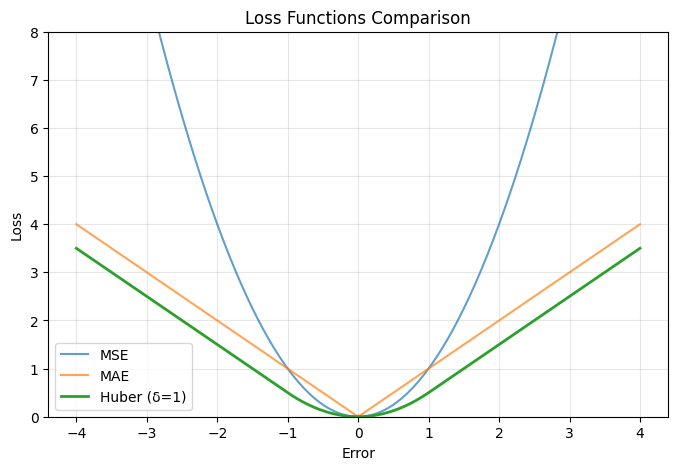

In [2]:
# Method 1: Simple function-based loss
def huber_loss_fn(y_true, y_pred, delta=1.0):
    """Huber loss: MSE when error < delta, MAE when error >= delta."""
    error = y_true - y_pred
    is_small = tf.abs(error) <= delta
    small_error = 0.5 * tf.square(error)
    large_error = delta * (tf.abs(error) - 0.5 * delta)
    return tf.where(is_small, small_error, large_error)

# Method 2: Class-based loss (configurable, serializable)
class HuberLoss(keras.losses.Loss):
    """Custom Huber Loss as a Keras Loss class.
    Advantage: configurable delta, serializable, works with model.save().
    """
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small = tf.abs(error) <= self.delta
        small_error = 0.5 * tf.square(error)
        large_error = self.delta * (tf.abs(error) - 0.5 * self.delta)
        return tf.reduce_mean(tf.where(is_small, small_error, large_error))

    def get_config(self):
        config = super().get_config()
        config["delta"] = self.delta
        return config

# Visualize Huber vs MSE vs MAE
errors = np.linspace(-4, 4, 200)
mse = errors**2
mae = np.abs(errors)
huber = np.where(np.abs(errors) <= 1, 0.5 * errors**2, np.abs(errors) - 0.5)

plt.figure(figsize=(8, 5))
plt.plot(errors, mse, label='MSE', alpha=0.7)
plt.plot(errors, mae, label='MAE', alpha=0.7)
plt.plot(errors, huber, label='Huber (δ=1)', linewidth=2)
plt.title('Loss Functions Comparison'); plt.xlabel('Error'); plt.ylabel('Loss')
plt.legend(); plt.ylim(0, 8); plt.grid(True, alpha=0.3); plt.show()

TF MSE: Test MAE = 0.3669
TF MAE: Test MAE = 0.3593
TF Huber: Test MAE = 0.8669


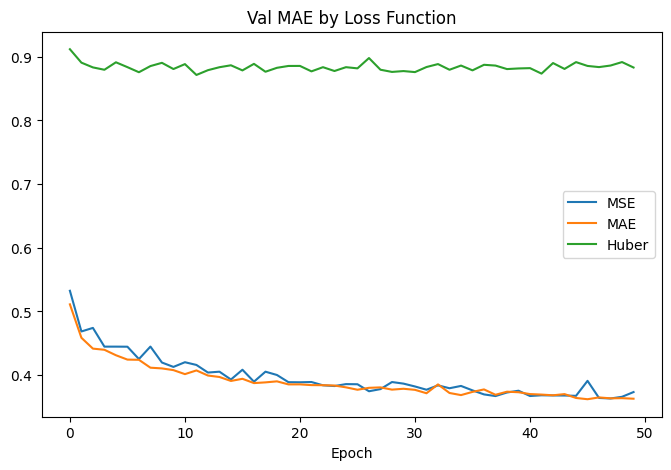

In [3]:
# Compare all three losses on California Housing
def build_regression_model():
    return keras.Sequential([
        layers.Input(shape=(8,)), layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'), layers.Dense(1)
    ])

results_tf = {}
for name, loss in [('MSE', 'mse'), ('MAE', 'mae'), ('Huber', HuberLoss(delta=1.0))]:
    model = build_regression_model()
    model.compile(optimizer='adam', loss=loss, metrics=['mae'])
    h = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=0)
    test_loss = model.evaluate(X_test, y_test, verbose=0)
    results_tf[name] = h
    print(f"TF {name}: Test MAE = {test_loss[1]:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
for name, h in results_tf.items(): ax.plot(h.history['val_mae'], label=name)
ax.set_title('Val MAE by Loss Function'); ax.legend(); ax.set_xlabel('Epoch'); plt.show()

In [4]:
# PyTorch: Custom Huber Loss
class HuberLossPT(nn.Module):
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        error = y_true - y_pred.squeeze()
        is_small = error.abs() <= self.delta
        small = 0.5 * error**2
        large = self.delta * (error.abs() - 0.5 * self.delta)
        return torch.where(is_small, small, large).mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
    batch_size=64, shuffle=True)

model = nn.Sequential(nn.Linear(8, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
huber = HuberLossPT(delta=1.0)

for ep in range(50):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); huber(model(xb), yb).backward(); opt.step()

model.eval()
with torch.no_grad():
    preds = model(torch.FloatTensor(X_test).to(device)).squeeze().cpu()
    mae = (preds - torch.FloatTensor(y_test)).abs().mean()
print(f"PyTorch Custom Huber: Test MAE = {mae:.4f}")

PyTorch Custom Huber: Test MAE = 0.3436


## Key Takeaways
- **MSE**: penalizes large errors heavily → sensitive to outliers
- **MAE**: equal penalty for all errors → robust but not differentiable at 0
- **Huber**: best of both — smooth at 0, linear for large errors → robust + differentiable
- In TF: subclass `keras.losses.Loss` for serializable custom losses
- In PyTorch: subclass `nn.Module` and implement `forward()`